# Import libraries

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import os
import re

from PIL import Image
from sklearn.model_selection import train_test_split

# Download data

In [27]:
def load_ordered_flow_data(data_dir, prefix="lam_", extension=".png"):
    """
    Загружает данные потока вокруг цилиндра из .png файлов с указанным префиксом и сортировкой по порядку номеров.
    
    Parameters:
        data_dir (str): Путь к папке с файлами .png.
        prefix (str): Префикс файлов, которые нужно загружать (например, "lam_" или "vv").
        extension (str): Расширение файлов (по умолчанию .png).
    
    Returns:
        np.ndarray: Массив данных (snapshots).
    """
    # Список файлов с указанным префиксом и расширением
    file_list = [f for f in os.listdir(data_dir) if f.startswith(prefix) and f.endswith(extension)]
    if not file_list:
        raise FileNotFoundError(f"В папке не найдено файлов с префиксом '{prefix}' и расширением '{extension}'")
    
    # Сортировка файлов по числовой части
    def extract_number(filename):
        match = re.search(rf"{prefix}(\d+)", filename)
        return int(match.group(1)) if match else float('inf')
    
    sorted_files = sorted(file_list, key=extract_number)
    
    data = []
    
    for file in sorted_files:
        file_path = os.path.join(data_dir, file)
        # Загрузка изображения
        img = Image.open(file_path).convert('L')  # Конвертация в градации серого
        img_array = np.array(img)  # Преобразование в numpy массив
        
        # Определение значимых пикселей (отсечение белых/желтых пикселей)
        threshold = 200  # Порог яркости для "значимого" пикселя
        mask = img_array < threshold  # Маска значимых пикселей

        # Определение границ обрезки
        rows = np.any(mask, axis=1)  # Найти строки с значимыми пикселями
        cols = np.any(mask, axis=0)  # Найти столбцы с значимыми пикселями
        row_start, row_end = np.where(rows)[0][[0, -1]]  # Границы строк
        col_start, col_end = np.where(cols)[0][[0, -1]]  # Границы столбцов

        # Обрезка изображения
        cropped_image = img_array[row_start:row_end+1, col_start:col_end+1]

        data.append(cropped_image)  # Преобразование в одномерный массив
    
    return np.array(data)

# Укажите путь к папке
data_dir = "/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/FluidFlowAroundCylinder/CFD_FluidFLow_data/elliptic_cylinder/Laminar/original_dataset"

# Загрузка данных с префиксом "lam_"
snapshots_lam = load_ordered_flow_data(data_dir, prefix="lam_")
print(f"Размер данных для 'lam_': {snapshots_lam.shape}")

# Загрузка данных с префиксом "vv"
snapshots_vv = load_ordered_flow_data(data_dir, prefix="vv")
print(f"Размер данных для 'vv': {snapshots_vv.shape}")

Размер данных для 'lam_': (60, 468, 1578)
Размер данных для 'vv': (64, 312, 1562)


## Data analys 

In [28]:
def generate_noisy_datasets(data, noise_level=0.1, num_noisy_datasets=5):
    """
    Создает несколько наборов данных с добавлением гауссова шума.
    
    Parameters:
        data (np.ndarray): Исходные данные.
        noise_level (float): Уровень шума.
        num_noisy_datasets (int): Количество наборов с шумом.
    
    Returns:
        list[np.ndarray]: Список наборов данных, включая оригинальный и с шумом.
    """
    datasets = [data]  # Оригинальные данные как первый набор
    for _ in range(num_noisy_datasets):
        noise = noise_level * np.random.normal(size=data.shape)
        datasets.append(data + noise)
    
    return datasets

# Пример использования
noisy_datasets = generate_noisy_datasets(snapshots_lam, noise_level=0.1, num_noisy_datasets=5)

# Построение расширенного датасета
extended_data = np.concatenate(noisy_datasets, axis=0)

# Размеры
print(f"Количество наборов данных: {len(noisy_datasets)}")
print(f"Размеры оригинального набора: {snapshots_lam.shape}")
for i, noisy_set in enumerate(noisy_datasets):
    print(f"Размеры набора данных {i + 1}: {noisy_set.shape}")

print(f"Размер расширенного датасета: {extended_data.shape}")

Количество наборов данных: 6
Размеры оригинального набора: (60, 468, 1578)
Размеры набора данных 1: (60, 468, 1578)
Размеры набора данных 2: (60, 468, 1578)
Размеры набора данных 3: (60, 468, 1578)
Размеры набора данных 4: (60, 468, 1578)
Размеры набора данных 5: (60, 468, 1578)
Размеры набора данных 6: (60, 468, 1578)
Размер расширенного датасета: (360, 468, 1578)


## Preprocessing data

In [29]:
def save_noisy_datasets_as_png(datasets, base_dir, prefix="dataset"):
    os.makedirs(base_dir, exist_ok=True)
    
    for i, dataset in enumerate(datasets):
        folder_name = f"{prefix}_{i}"
        folder_path = os.path.join(base_dir, folder_name)
        os.makedirs(folder_path, exist_ok=True)
        
        for j, snapshot in enumerate(dataset):
            if snapshot.ndim != 2:
                raise ValueError(f"Snapshot {j} in dataset {i} is not 2D.")
            
            # Clip between 0 and 255 for 8-bit grayscale images
            snapshot_clipped = np.clip(snapshot, 0, 255)
            img = Image.fromarray(snapshot_clipped.astype(np.uint8))
            
            file_path = os.path.join(folder_path, f"snapshot_{j}.png")
            img.save(file_path)
    
    print(f"Datasets saved to PNG in folder: {base_dir}")

# Пример использования
base_dir = "/Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/FluidFlowAroundCylinder/CFD_FluidFLow_data/elliptic_cylinder/Laminar/noisy_datasets"

# Сохранение наборов данных
save_noisy_datasets_as_png(noisy_datasets, base_dir, prefix="noisy_dataset")

Datasets saved to PNG in folder: /Users/denissamatov/Heriot-Watt/tensor-based_modal_decomposition_method/data/FluidFlowAroundCylinder/CFD_FluidFLow_data/elliptic_cylinder/Laminar/noisy_datasets


## Split data

In [30]:
# Деление на обучающую и тестовую выборки
train_data, test_data = train_test_split(extended_data, test_size=0.2, random_state=42)

print(f"Размер обучающей выборки: {train_data.shape}")
print(f"Размер тестовой выборки: {test_data.shape}")

Размер обучающей выборки: (288, 468, 1578)
Размер тестовой выборки: (72, 468, 1578)


In [31]:
print(f"Размер данных: {train_data[0].shape}")  # Узнаем текущую форму первого снимка
print(f"Общее количество элементов: {train_data[0].size}")

Размер данных: (468, 1578)
Общее количество элементов: 738504


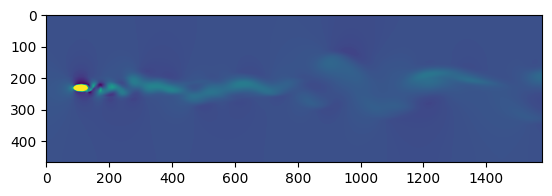

In [32]:
# Отобразим первый снимок из обучающей выборки
snapshot = train_data[0]  # Размер должен совпадать с разрешением данных
plt.imshow(snapshot, cmap='viridis')
plt.show()

In [33]:
snapshot

array([[61.97793078, 61.78052251, 62.19938546, ..., 61.89786404,
        62.05996551, 62.11585585],
       [62.07166073, 61.70270973, 61.92957516, ..., 62.17029879,
        62.0561784 , 61.94286949],
       [61.99411258, 61.86188379, 61.98523509, ..., 62.01395958,
        61.92334785, 61.97582354],
       ...,
       [62.99979194, 63.02057679, 62.99735076, ..., 61.91644283,
        62.02206226, 62.12505553],
       [62.97348251, 63.09781121, 62.95509735, ..., 62.05264261,
        62.02404937, 62.16556337],
       [62.88735057, 63.0148222 , 63.09491758, ..., 61.7487066 ,
        62.0169294 , 62.15394222]])